### Importación de Datos

In [ ]:
#importamos las librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno
from google.colab import data_table
from IPython.display import display

# Configuración para que los gráficos se vean mejor
%matplotlib inline
sns.set_theme(style="whitegrid")

print("Librerías listas para la limpieza.")


Librerías listas para la limpieza.


#### Carga del Dataset

In [ ]:
df_data = pd.read_csv('all-states-history.csv')
df_data_raw = df_data.copy()
df_data

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20775,2020-01-17,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0
20776,2020-01-16,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0
20777,2020-01-15,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0
20778,2020-01-14,WA,NaN,NaN,0,NaN,NaN,NaN,NaN,0,...,NaN,0,NaN,NaN,NaN,NaN,NaN,0,NaN,0


In [ ]:
df_data.describe()

,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,inIcuCumulative,inIcuCurrently,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
count,19930.000000,9422.000000,20780.000000,7593.000000,12382.000000,12382.000000,17339.000000,20780.000000,3789.000000,11636.000000,...,2.061400e+04,20780.000000,4.789000e+03,3.421000e+03,2200.000000,999.000000,9.197000e+03,2.078000e+04,1.451600e+04,2.078000e+04
mean,3682.216859,3770.182764,24.790712,417.291321,9262.762478,9262.762478,1190.576965,37.360780,1934.191607,359.621176,...,2.186936e+06,17508.388210,1.634028e+05,3.089196e+05,165431.783182,168188.246246,9.650105e+05,2.739554e+03,2.304555e+06,1.296143e+04
std,6281.366321,4157.640633,60.162742,537.625982,12620.544081,12620.544081,2060.041207,208.237151,1953.329983,594.831150,...,4.436508e+06,33586.022461,2.016978e+05,4.232854e+05,178181.836898,143748.073365,1.415215e+06,1.621900e+04,4.445365e+06,3.749509e+04
min,0.000000,0.000000,-201.000000,0.000000,1.000000,1.000000,0.000000,-12257.000000,6.000000,0.000000,...,0.000000e+00,-130545.000000,0.000000e+00,1.000000e+00,1.000000,3.000000,0.000000e+00,-1.043744e+06,0.000000e+00,-1.154583e+06
25%,161.250000,607.000000,0.000000,79.000000,985.250000,985.250000,166.500000,0.000000,501.000000,60.000000,...,1.040498e+05,1205.750000,1.896500e+04,2.004700e+04,54912.750000,37675.500000,1.414700e+05,0.000000e+00,1.324600e+05,0.000000e+00
50%,1108.000000,2409.500000,6.000000,216.000000,4472.000000,4472.000000,531.000000,0.000000,1295.000000,172.000000,...,6.552670e+05,6125.000000,8.465200e+04,1.233840e+05,103967.500000,144130.000000,4.193720e+05,0.000000e+00,7.316510e+05,1.896500e+03
75%,4387.500000,5462.000000,24.000000,460.000000,12248.500000,12248.500000,1279.000000,36.000000,2451.000000,380.000000,...,2.264766e+06,19086.500000,2.300110e+05,4.327270e+05,183103.000000,255251.000000,1.229298e+06,2.478000e+03,2.496925e+06,1.244100e+04
max,54124.000000,21177.000000,2559.000000,2594.000000,82237.000000,82237.000000,22851.000000,16373.000000,9263.000000,5225.000000,...,4.964601e+07,473076.000000,1.054711e+06,2.664340e+06,995580.000000,580372.000000,1.124825e+07,8.208170e+05,4.964601e+07,2.164543e+06


##### Funciones para hacer radiografía inicial



In [ ]:
# Se realiza un análisis técnico , "data quality check" para analizar el dataset de forma automática y entender su calidad

# Función 1 :radiografía técnica
def radiografia_tecnica(df):
    print("="*60)
    print(f"{' RADIOGRAFÍA DEL DATASET -#SNAPSHOT-':^60}")
    print("="*60)

    # 1. Dimensiones básicas
    filas, columnas = df.shape
    nulos_totales = df.isnull().sum().sum()
    duplicados = df.duplicated().sum()
    memoria = df.memory_usage(deep=True).sum() / (1024**2) # En MB

    print(f"  • Filas: {filas:,}")
    print(f"  • Columnas: {columnas}")
    print(f"  • Celdas totales: {df.size:,}")
    print(f"  • Datos faltantes: {nulos_totales:,} ({ (nulos_totales/df.size)*100:.2f}%)" if df.size > 0 else "  • Datos faltantes: 0")
    print(f"  • Filas duplicadas: {duplicados}")
    print(f"  • Uso de memoria: {memoria:.2f} MB")
    print("-" * 60)

    # 2. Análisis detallado por columna
    resumen_cols = pd.DataFrame({
        'Tipo': df.dtypes,
        'No Nulos': df.count(),
        'Nulos': df.isnull().sum(),
        '% Nulos': (df.isnull().sum() / filas) * 100,
        'Unicos': df.nunique(),
        'Cardinalidad (%)': (df.nunique() / filas) * 100
    })

    # Ejemplo de datos
    resumen_cols['Ejemplo'] = [df[col].dropna().iloc[0] if not df[col].dropna().empty else "N/A" for col in df.columns]

    display(resumen_cols.style.format({'% Nulos': '{:.2f}%', 'Cardinalidad (%)': '{:.2f}%'}) \
        .background_gradient(cmap='Reds', subset=['% Nulos']) \
        .set_table_styles([{'selector': 'th', 'props': [('text-align', 'left')]},
                           {'selector': 'td', 'props': [('text-align', 'left')]}]))

    print("-" * 60)
    print(f"{' ESTADÍSTICAS NUMÉRICAS ':^60}")
    display(df.describe().T)

    print("-" * 60)
    print(f"{' DISTRIBUCIÓN DE NULOS (VISUAL) ':^60}")
    msno.matrix(df, figsize=(10,4), fontsize=9)
    plt.show()


# Función 2: El plan de acción (Resumen adaptado)
def plan_accion_datos(df):
    print("\n" + "="*60)
    print(f"{' 🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO ':^60}")
    print("="*60)

    # Duplicados
    duplicados = df.duplicated().sum()
    if duplicados > 0:
        print(f"  [ ] DUPLICADOS: Eliminar {duplicados} filas repetidas.")

    # Nulos
    nulos_criticos = df.columns[df.isnull().sum() / len(df) > 0.3].tolist()
    if nulos_criticos:
        print(f"  [ ] NULOS: Revisar columnas con >30% de vacío: {nulos_criticos}")

    # Montos (amount)
    if 'amount' in df.columns:
        anomalos = (df['amount'] < 0).sum()
        if anomalos > 0:
            print(f"  [ ] VALORES: Revisar {anomalos} registros con 'amount' negativo.")

    # Fechas (Específicas de tu tabla: rental_date, return_date)
    cols_fecha = [col for col in df.columns if 'date' in col.lower() or 'time' in col.lower()]
    cols_a_convertir = [col for col in cols_fecha if not pd.api.types.is_datetime64_any_dtype(df[col])]

    if cols_a_convertir:
        print(f"  [ ] FORMATO: Convertir a datetime: {cols_a_convertir}")

    print("-" * 60)
    print("  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.")
    print("="*60)

# Función 3: Comparativo Snapshot (Sin cambios, es universal)
def comparativo_snapshot(df_inicial, df_final):
    print("="*60)
    print(f"{' ⚖️ COMPARATIVA DE CALIDAD DE DATOS ':^60}")
    print("="*60)

    def get_metrics(df):
        return [
            f"{len(df):,}",
            df.shape[1],
            f"{df.isnull().sum().sum():,}",
            f"{(df.isnull().sum().sum() / df.size * 100 if df.size > 0 else 0):.2f}%",
            df.duplicated().sum(),
            f"{df.memory_usage(deep=True).sum() / (1024**2):.2f}"
        ]

    metrics = {
        'Métrica': ['Filas Totales', 'Columnas', 'Celdas con Nulos', '% Global de Nulos', 'Filas Duplicadas', 'Memoria (MB)'],
        'Snapshot Inicial': get_metrics(df_inicial),
        'Snapshot Final': get_metrics(df_final)
    }

    comparativa_df = pd.DataFrame(metrics)

    display(comparativa_df.style.set_properties(**{'text-align': 'center'})
            .set_table_styles([{'selector': 'th', 'props': [('background-color', '#f0f2f6')]}])
            .hide(axis='index'))

    eliminadas = len(df_inicial) - len(df_final)
    print(f"\n✅ Se han depurado {eliminadas:,} filas en total.")
    print("="*60)

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 20,780
  • Columnas: 41
  • Celdas totales: 851,980
  • Datos faltantes: 373,695 (43.86%)
  • Filas duplicadas: 0
  • Uso de memoria: 8.36 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
date,object,20780,0,0.00%,420,2.02%,2021-03-07
state,object,20780,0,0.00%,56,0.27%,AK
death,float64,19930,850,4.09%,7476,35.98%,305.000000
deathConfirmed,float64,9422,11358,54.66%,5377,25.88%,7963.000000
deathIncrease,int64,20780,0,0.00%,429,2.06%,0
deathProbable,float64,7593,13187,63.46%,1392,6.70%,2185.000000
hospitalized,float64,12382,8398,40.41%,7571,36.43%,1293.000000
hospitalizedCumulative,float64,12382,8398,40.41%,7571,36.43%,1293.000000
hospitalizedCurrently,float64,17339,3441,16.56%,3885,18.70%,33.000000
hospitalizedIncrease,int64,20780,0,0.00%,566,2.72%,0


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,std,min,25%,50%,75%,max
death,19930.0,3.682217e+03,6.281366e+03,0.0,161.25,1108.0,4387.50,54124.0
deathConfirmed,9422.0,3.770183e+03,4.157641e+03,0.0,607.00,2409.5,5462.00,21177.0
deathIncrease,20780.0,2.479071e+01,6.016274e+01,-201.0,0.00,6.0,24.00,2559.0
deathProbable,7593.0,4.172913e+02,5.376260e+02,0.0,79.00,216.0,460.00,2594.0
hospitalized,12382.0,9.262762e+03,1.262054e+04,1.0,985.25,4472.0,12248.50,82237.0
hospitalizedCumulative,12382.0,9.262762e+03,1.262054e+04,1.0,985.25,4472.0,12248.50,82237.0
hospitalizedCurrently,17339.0,1.190577e+03,2.060041e+03,0.0,166.50,531.0,1279.00,22851.0
hospitalizedIncrease,20780.0,3.736078e+01,2.082372e+02,-12257.0,0.00,0.0,36.00,16373.0
inIcuCumulative,3789.0,1.934192e+03,1.953330e+03,6.0,501.00,1295.0,2451.00,9263.0
inIcuCurrently,11636.0,3.596212e+02,5.948311e+02,0.0,60.00,172.0,380.00,5225.0


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


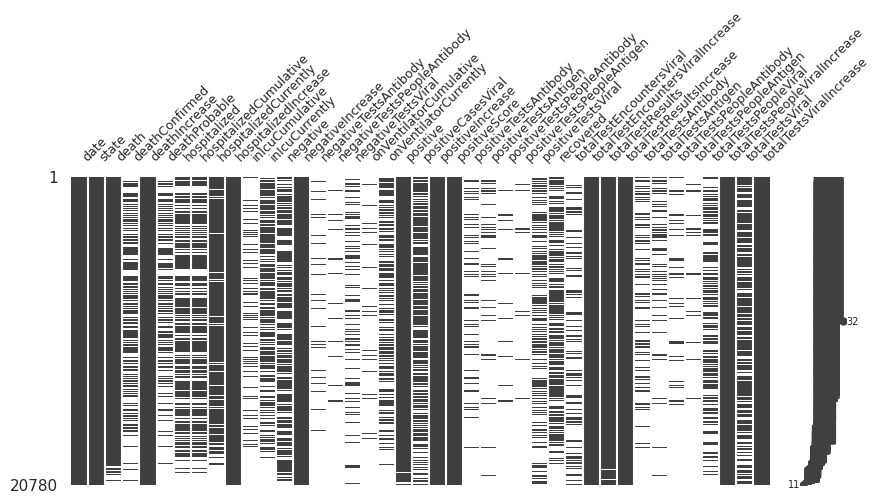


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
  [ ] NULOS: Revisar columnas con >30% de vacío: ['deathConfirmed', 'deathProbable', 'hospitalized', 'hospitalizedCumulative', 'inIcuCumulative', 'inIcuCurrently', 'negative', 'negativeTestsAntibody', 'negativeTestsPeopleAntibody', 'negativeTestsViral', 'onVentilatorCumulative', 'onVentilatorCurrently', 'positiveCasesViral', 'positiveTestsAntibody', 'positiveTestsAntigen', 'positiveTestsPeopleAntibody', 'positiveTestsPeopleAntigen', 'positiveTestsViral', 'recovered', 'totalTestEncountersViral', 'totalTestsAntibody', 'totalTestsAntigen', 'totalTestsPeopleAntibody', 'totalTestsPeopleAntigen', 'totalTestsPeopleViral', 'totalTestsViral']
  [ ] FORMATO: Convertir a datetime: ['date']
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.


In [ ]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df_data)

# Para ver qué deberías limpiar:
plan_accion_datos(df_data)

### Limpieza de datos

In [ ]:
df_data.isnull().sum()

,0
date,0
state,0
death,850
deathConfirmed,11358
deathIncrease,0
deathProbable,13187
hospitalized,8398
hospitalizedCumulative,8398
hospitalizedCurrently,3441
hospitalizedIncrease,0


In [ ]:
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   date                              20780 non-null  object 
 1   state                             20780 non-null  object 
 2   death                             19930 non-null  float64
 3   deathConfirmed                    9422 non-null   float64
 4   deathIncrease                     20780 non-null  int64  
 5   deathProbable                     7593 non-null   float64
 6   hospitalized                      12382 non-null  float64
 7   hospitalizedCumulative            12382 non-null  float64
 8   hospitalizedCurrently             17339 non-null  float64
 9   hospitalizedIncrease              20780 non-null  int64  
 10  inIcuCumulative                   3789 non-null   float64
 11  inIcuCurrently                    11636 non-null  float64
 12  nega

In [ ]:
df_data.head(20)

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,NaN,0,NaN,1293.0,1293.0,33.0,0,...,1731628.0,0,NaN,NaN,NaN,NaN,NaN,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,NaN,NaN,119757.0,NaN,2323788.0,2347,NaN,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,NaN,NaN,NaN,481311.0,NaN,0,2736442.0,3380
3,2021-03-07,AS,0.0,NaN,0,NaN,NaN,NaN,NaN,0,...,2140.0,0,NaN,NaN,NaN,NaN,NaN,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,NaN,444089.0,NaN,3842945.0,14856,7908105.0,45110
5,2021-03-07,CA,54124.0,NaN,258,NaN,NaN,NaN,4291.0,0,...,49646014.0,133186,NaN,NaN,NaN,NaN,NaN,0,49646014.0,133186
6,2021-03-07,CO,5989.0,5251.0,3,735.0,23904.0,23904.0,326.0,18,...,6415123.0,38163,435053.0,NaN,NaN,NaN,2616541.0,6107,NaN,0
7,2021-03-07,CT,7704.0,6327.0,0,1377.0,NaN,NaN,428.0,0,...,6520366.0,0,NaN,396680.0,NaN,NaN,NaN,0,6520366.0,0
8,2021-03-07,DC,1030.0,NaN,0,NaN,NaN,NaN,150.0,0,...,1261363.0,5726,NaN,NaN,NaN,NaN,441942.0,1149,NaN,0
9,2021-03-07,DE,1473.0,1337.0,9,136.0,NaN,NaN,104.0,0,...,1431942.0,5867,NaN,NaN,NaN,NaN,633424.0,1132,NaN,0


In [ ]:
df_data['state'] = df_data['state'].str.strip().str.upper()      # Elimina espacios sobrantes

In [ ]:
df_data['date'] = pd.to_datetime(df_data['date'])

### Comprobacion de duplicados

In [ ]:
df_data.duplicated().sum()

np.int64(0)

In [ ]:
df_data = df_data.fillna(0)

In [ ]:
df_data

,date,state,death,deathConfirmed,deathIncrease,deathProbable,hospitalized,hospitalizedCumulative,hospitalizedCurrently,hospitalizedIncrease,...,totalTestResults,totalTestResultsIncrease,totalTestsAntibody,totalTestsAntigen,totalTestsPeopleAntibody,totalTestsPeopleAntigen,totalTestsPeopleViral,totalTestsPeopleViralIncrease,totalTestsViral,totalTestsViralIncrease
0,2021-03-07,AK,305.0,0.0,0,0.0,1293.0,1293.0,33.0,0,...,1731628.0,0,0.0,0.0,0.0,0.0,0.0,0,1731628.0,0
1,2021-03-07,AL,10148.0,7963.0,-1,2185.0,45976.0,45976.0,494.0,0,...,2323788.0,2347,0.0,0.0,119757.0,0.0,2323788.0,2347,0.0,0
2,2021-03-07,AR,5319.0,4308.0,22,1011.0,14926.0,14926.0,335.0,11,...,2736442.0,3380,0.0,0.0,0.0,481311.0,0.0,0,2736442.0,3380
3,2021-03-07,AS,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,2140.0,0,0.0,0.0,0.0,0.0,0.0,0,2140.0,0
4,2021-03-07,AZ,16328.0,14403.0,5,1925.0,57907.0,57907.0,963.0,44,...,7908105.0,45110,580569.0,0.0,444089.0,0.0,3842945.0,14856,7908105.0,45110
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20775,2020-01-17,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0
20776,2020-01-16,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0
20777,2020-01-15,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0
20778,2020-01-14,WA,0.0,0.0,0,0.0,0.0,0.0,0.0,0,...,0.0,0,0.0,0.0,0.0,0.0,0.0,0,0.0,0


### Comprobación de cambios de formatos

In [ ]:
df_data.dtypes

,0
date,datetime64[ns]
state,object
death,float64
deathConfirmed,float64
deathIncrease,int64
deathProbable,float64
hospitalized,float64
hospitalizedCumulative,float64
hospitalizedCurrently,float64
hospitalizedIncrease,int64


In [ ]:
df_data.info()
df_data.head()
df_data.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20780 entries, 0 to 20779
Data columns (total 41 columns):
 #   Column                            Non-Null Count  Dtype         
---  ------                            --------------  -----         
 0   date                              20780 non-null  datetime64[ns]
 1   state                             20780 non-null  object        
 2   death                             20780 non-null  float64       
 3   deathConfirmed                    20780 non-null  float64       
 4   deathIncrease                     20780 non-null  int64         
 5   deathProbable                     20780 non-null  float64       
 6   hospitalized                      20780 non-null  float64       
 7   hospitalizedCumulative            20780 non-null  float64       
 8   hospitalizedCurrently             20780 non-null  float64       
 9   hospitalizedIncrease              20780 non-null  int64         
 10  inIcuCumulative                   20780 non-nu

Index(['date', 'state', 'death', 'deathConfirmed', 'deathIncrease',
       'deathProbable', 'hospitalized', 'hospitalizedCumulative',
       'hospitalizedCurrently', 'hospitalizedIncrease', 'inIcuCumulative',
       'inIcuCurrently', 'negative', 'negativeIncrease',
       'negativeTestsAntibody', 'negativeTestsPeopleAntibody',
       'negativeTestsViral', 'onVentilatorCumulative', 'onVentilatorCurrently',
       'positive', 'positiveCasesViral', 'positiveIncrease', 'positiveScore',
       'positiveTestsAntibody', 'positiveTestsAntigen',
       'positiveTestsPeopleAntibody', 'positiveTestsPeopleAntigen',
       'positiveTestsViral', 'recovered', 'totalTestEncountersViral',
       'totalTestEncountersViralIncrease', 'totalTestResults',
       'totalTestResultsIncrease', 'totalTestsAntibody', 'totalTestsAntigen',
       'totalTestsPeopleAntibody', 'totalTestsPeopleAntigen',
       'totalTestsPeopleViral', 'totalTestsPeopleViralIncrease',
       'totalTestsViral', 'totalTestsViralIncrease'

             RADIOGRAFÍA DEL DATASET -#SNAPSHOT-            
  • Filas: 20,780
  • Columnas: 41
  • Celdas totales: 851,980
  • Datos faltantes: 0 (0.00%)
  • Filas duplicadas: 0
  • Uso de memoria: 7.35 MB
------------------------------------------------------------


,Tipo,No Nulos,Nulos,% Nulos,Unicos,Cardinalidad (%),Ejemplo
date,datetime64[ns],20780,0,0.00%,420,2.02%,2021-03-07 00:00:00
state,object,20780,0,0.00%,56,0.27%,AK
death,float64,20780,0,0.00%,7476,35.98%,305.000000
deathConfirmed,float64,20780,0,0.00%,5377,25.88%,0.000000
deathIncrease,int64,20780,0,0.00%,429,2.06%,0
deathProbable,float64,20780,0,0.00%,1392,6.70%,0.000000
hospitalized,float64,20780,0,0.00%,7572,36.44%,1293.000000
hospitalizedCumulative,float64,20780,0,0.00%,7572,36.44%,1293.000000
hospitalizedCurrently,float64,20780,0,0.00%,3885,18.70%,33.000000
hospitalizedIncrease,int64,20780,0,0.00%,566,2.72%,0


------------------------------------------------------------
                   ESTADÍSTICAS NUMÉRICAS                   


,count,mean,min,25%,50%,75%,max,std
date,20780,2020-09-02 18:13:30.779595776,2020-01-13 00:00:00,2020-06-02 00:00:00,2020-09-03 00:00:00,2020-12-05 00:00:00,2021-03-07 00:00:00,NaN
death,20780.0,3531.596824,0.0,118.0,982.0,4159.0,54124.0,6194.636505
deathConfirmed,20780.0,1709.464004,0.0,0.0,0.0,1921.0,21177.0,3370.488127
deathIncrease,20780.0,24.790712,-201.0,0.0,6.0,24.0,2559.0,60.162742
deathProbable,20780.0,152.478008,0.0,0.0,0.0,114.0,2594.0,382.08244
hospitalized,20780.0,5519.322666,0.0,0.0,462.0,6411.0,82237.0,10750.201894
hospitalizedCumulative,20780.0,5519.322666,0.0,0.0,462.0,6411.0,82237.0,10750.201894
hospitalizedCurrently,20780.0,993.427045,0.0,46.0,370.0,1051.0,22851.0,1933.09738
hospitalizedIncrease,20780.0,37.36078,-12257.0,0.0,0.0,36.0,16373.0,208.237151
inIcuCumulative,20780.0,352.678152,0.0,0.0,0.0,0.0,9263.0,1119.533486


------------------------------------------------------------
               DISTRIBUCIÓN DE NULOS (VISUAL)               


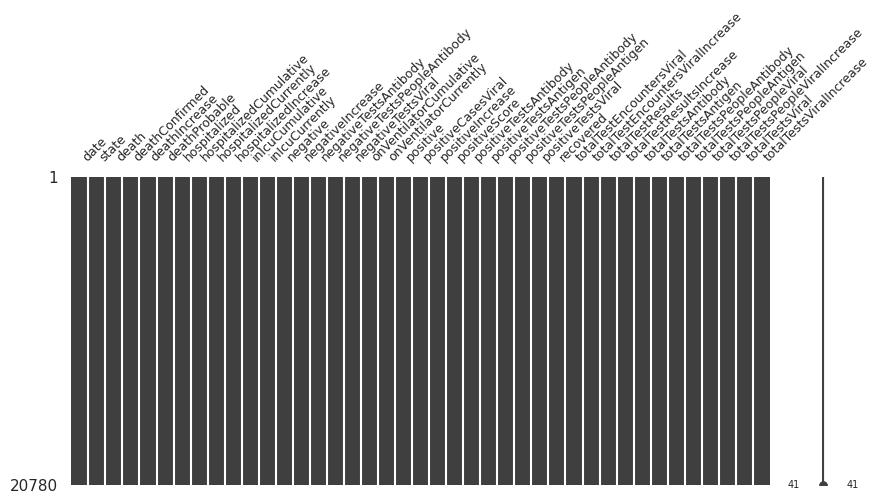


           🚀 RESUMEN: PLAN DE ACCIÓN RECOMENDADO            
------------------------------------------------------------
  TIP: Los campos de fecha actuales son 'object'. Cámbialos para análisis temporal.
             ⚖️ COMPARATIVA DE CALIDAD DE DATOS             


Métrica,Snapshot Inicial,Snapshot Final
Filas Totales,"20,780","20,780"
Columnas,41,41
Celdas con Nulos,"373,695",0
% Global de Nulos,43.86%,0.00%
Filas Duplicadas,0,0
Memoria (MB),8.36,7.35



✅ Se han depurado 0 filas en total.


In [ ]:
# Para ver el estado actual de tus 15,861 filas:
radiografia_tecnica(df_data)

# Para ver qué deberías limpiar:
plan_accion_datos(df_data)

#Comparativa
comparativo_snapshot(df_data_raw, df_data)

In [ ]:
for col in df_data.columns:
    print(f"\n--- {col} ---")
    print(df_data[col].value_counts(dropna=False).head(20))


--- date ---
date
2020-03-16    56
2020-03-17    56
2020-03-18    56
2020-03-19    56
2020-03-20    56
2021-02-04    56
2021-02-05    56
2021-02-06    56
2021-02-07    56
2021-02-08    56
2021-02-09    56
2021-02-10    56
2021-02-11    56
2021-02-12    56
2021-02-13    56
2021-02-14    56
2021-02-15    56
2021-02-16    56
2021-02-17    56
2021-02-18    56
Name: count, dtype: int64

--- state ---
state
WA    420
MA    411
VA    406
FL    404
NJ    392
NE    387
IN    375
CT    373
RI    372
MI    372
WY    372
NY    371
VT    370
PA    370
TX    370
WI    370
HI    369
IL    369
NC    369
NH    369
Name: count, dtype: int64

--- death ---
death
0.0     1402
2.0      421
5.0      178
1.0      150
6.0      120
17.0     109
58.0     107
23.0      88
10.0      76
7.0       75
9.0       73
3.0       73
24.0      70
4.0       65
16.0      61
56.0      57
20.0      55
25.0      53
19.0      52
18.0      50
Name: count, dtype: int64

--- deathConfirmed ---
deathConfirmed
0.0       11391
2.0   

#REPRESENTACIÓN DE DATOS